# 1. 📚 Importar librerias

In [59]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from os.path import basename

# 2. 📊 Cargar csv/df

In [60]:
df = pd.read_csv('../data/raw/2023-03-08 Precios Casas RM.csv')
df = df.copy()

# 3. 🔬 EDA

In [61]:
df.head()

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
0,409285000,11500,509695,QuintaNormal,Hoevel4548y4558,7,4.0,384.0,732.0,3.0,11700213,NaN
1,105000000,2950,130760,PedroAguirreCerda,Rucalhue,2,1.0,112.0,145.0,1.0,10894299,Legales y Propiedades SpA
2,128124000,3600,159557,EstaciónCentral,AvenidaLasParcelas,3,1.0,59.0,243.0,2.0,10257635,Propiedadesrs
3,75000000,2107,93400,Colina,PasajeGonzaloRojas,3,1.0,103.0,73.0,1.0,9232092,Patricio Gajardo propiedades
4,53000000,1489,66002,Colina,HernánDíazArrieta2820,2,1.0,57.0,67.0,1.0,7085397,Patricio Gajardo propiedades


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7779 entries, 0 to 7778
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price_CLP   7779 non-null   int64  
 1   Price_UF    7779 non-null   int64  
 2   Price_USD   7779 non-null   int64  
 3   Comuna      7779 non-null   object 
 4   Ubicacion   7779 non-null   object 
 5   Dorms       7779 non-null   int64  
 6   Baths       7714 non-null   float64
 7   Built Area  7533 non-null   float64
 8   Total Area  7571 non-null   float64
 9   Parking     5489 non-null   float64
 10  id          7779 non-null   int64  
 11  Realtor     7184 non-null   object 
dtypes: float64(4), int64(5), object(3)
memory usage: 729.4+ KB


In [63]:
df.describe().style.format("{:,.2f}")

,Price_CLP,Price_UF,Price_USD,Dorms,Baths,Built Area,Total Area,Parking,id
count,"7,779.00","7,779.00","7,779.00","7,779.00","7,714.00","7,533.00","7,571.00","5,489.00","7,779.00"
mean,"364,248,117.63","10,234.57","453,609.11",3.99,2.65,229.92,807.92,2.98,"9,910,827.69"
std,"386,880,986.22","10,870.49","481,794.50",1.62,1.47,"1,676.90","9,050.89",17.75,"2,046,316.67"
min,"2,085.00",0.00,3.00,1.00,1.00,1.00,1.00,1.00,"1,213,620.00"
25%,"120,000,000.00","3,372.00","149,440.00",3.00,2.00,85.00,129.50,1.00,"8,563,078.50"
50%,"205,000,000.00","5,760.00","255,293.00",4.00,2.00,128.00,210.00,2.00,"10,548,072.00"
75%,"491,142,000.00","13,800.00","611,634.00",5.00,3.00,200.00,443.00,3.00,"11,524,632.00"
max,"5,516,450,000.00","155,000.00","6,869,801.00",27.00,29.00,"120,000.00","678,000.00","1,269.00","12,341,490.00"


## 3.1 ☣️ Datos anomalos

<b>Nulos por columna</b>

In [64]:
df.isnull().sum()

Price_CLP        0
Price_UF         0
Price_USD        0
Comuna           0
Ubicacion        0
Dorms            0
Baths           65
Built Area     246
Total Area     208
Parking       2290
id               0
Realtor        595
dtype: int64

In [65]:
cols = ['Baths', 'Built Area', 'Total Area', 'Parking', 'Realtor']
for col in cols:
    print(f'% de datos que son nulos para "{col}": { ( ( df[col].isnull().sum() / df.shape[0] ) * 100 ).round(2) }%')

% de datos que son nulos para "Baths": 0.84%
% de datos que son nulos para "Built Area": 3.16%
% de datos que son nulos para "Total Area": 2.67%
% de datos que son nulos para "Parking": 29.44%
% de datos que son nulos para "Realtor": 7.65%


**Matamos los < 5%**

In [66]:
df = df.dropna(subset=['Baths', 'Built Area', 'Total Area'])

**Duplicados**

In [67]:
df[df.duplicated()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor
5584,266925000,7500,332410,Tiltil,Sevendecasaconampliaparcelaentiltil,4,3.0,250.0,6000.0,1.0,10215663,Movahome Corredores Integrados


**Lo matamos**

In [68]:
df = df.drop_duplicates()
df[df.duplicated()]

,Price_CLP,Price_UF,Price_USD,Comuna,Ubicacion,Dorms,Baths,Built Area,Total Area,Parking,id,Realtor


**Buscamos outliers**

In [69]:
# Regla:
# Outlier si x < Q1 - 1.5*IQR o x > Q3 + 1.5*IQR

def detectar_outliers_iqr(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mascara = (serie < limite_inferior) | (serie > limite_superior)

    return mascara, limite_inferior, limite_superior

df_check = df.drop(columns=['Comuna', 'Ubicacion', 'Realtor', 'id'])
outlier_mask = pd.Series(False, index=df_check.index)

for name in df_check:
    mask_iqr, li, ls = detectar_outliers_iqr(df_check[name])
    print(f"Límites IQR para {name}:")
    print(f"Inferior: {li:.2f} | Superior: {ls:.2f}")
    print(f"Cantidad de outliers en {name} (IQR): {mask_iqr.sum()}\n")
    outlier_mask |= mask_iqr

Límites IQR para Price_CLP:
Inferior: -446783493.75 | Superior: 1064716656.25
Cantidad de outliers en Price_CLP (IQR): 416

Límites IQR para Price_UF:
Inferior: -12553.12 | Superior: 29915.88
Cantidad de outliers en Price_UF (IQR): 416

Límites IQR para Price_USD:
Inferior: -556392.50 | Superior: 1325923.50
Cantidad de outliers en Price_USD (IQR): 416

Límites IQR para Dorms:
Inferior: 0.00 | Superior: 8.00
Cantidad de outliers en Dorms (IQR): 117

Límites IQR para Baths:
Inferior: 0.50 | Superior: 4.50
Cantidad de outliers en Baths (IQR): 725

Límites IQR para Built Area:
Inferior: -87.50 | Superior: 372.50
Cantidad de outliers en Built Area (IQR): 561

Límites IQR para Total Area:
Inferior: -338.00 | Superior: 910.00
Cantidad de outliers en Total Area (IQR): 857

Límites IQR para Parking:
Inferior: -2.00 | Superior: 6.00
Cantidad de outliers en Parking (IQR): 270



**Tenemos valores inferiores negativos, consideraremos valores coherentes al negocio. <br>Con los limites superiores podemos definir el otro extremo para filtar**

In [70]:
df_clean = df[
                (df['Price_UF'] > 500) & (df['Price_UF'] < 29915) &
                (df['Total Area'] > 42) & (df['Total Area'] < 910) &
                (df['Built Area'] > 42) & (df['Built Area'] < 373) &
                (df['Baths'] > 0) & (df['Baths'] < 5)
            ].copy()

**Aun quedan valores NA, los limpiamos**

In [71]:
df_clean['Parking'] = df_clean['Parking'].fillna(0)

df_clean['Realtor'] = df_clean['Realtor'].fillna('Desconocido')


**Hay columnas que no necesitamos, las sacamos**

In [72]:
df_clean = df_clean.drop(columns=['Price_CLP', 'Price_USD', 'Ubicacion', 'id', 'Realtor'])

# 4. 📐 Vectorizacion

In [73]:
df_clean['UF_m2'] = (df_clean['Price_UF'] / df_clean['Built Area']).round(2)
df_clean.head()

,Price_UF,Comuna,Dorms,Baths,Built Area,Total Area,Parking,UF_m2
1,2950,PedroAguirreCerda,2,1.0,112.0,145.0,1.0,26.34
2,3600,EstaciónCentral,3,1.0,59.0,243.0,2.0,61.02
3,2107,Colina,3,1.0,103.0,73.0,1.0,20.46
4,1489,Colina,2,1.0,57.0,67.0,1.0,26.12
5,2641,EstaciónCentral,2,1.0,72.0,131.0,0.0,36.68


# 5. 📈 Correlacion

<Axes: >

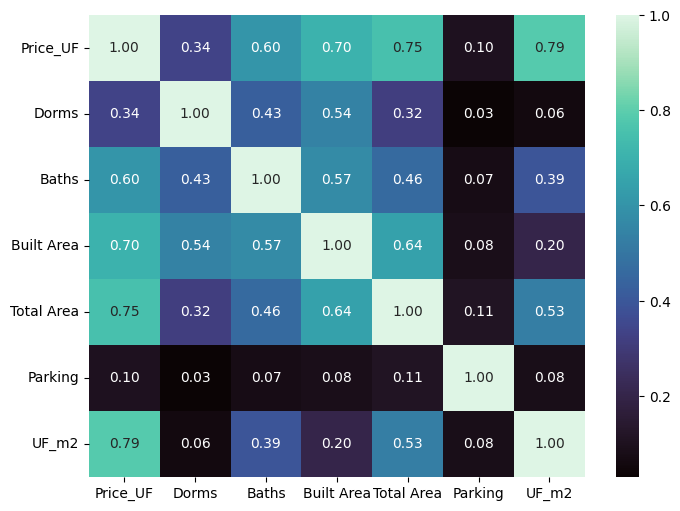

In [74]:
corr = df_clean.select_dtypes('number').corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='mako',
            fmt='.2f'
            )

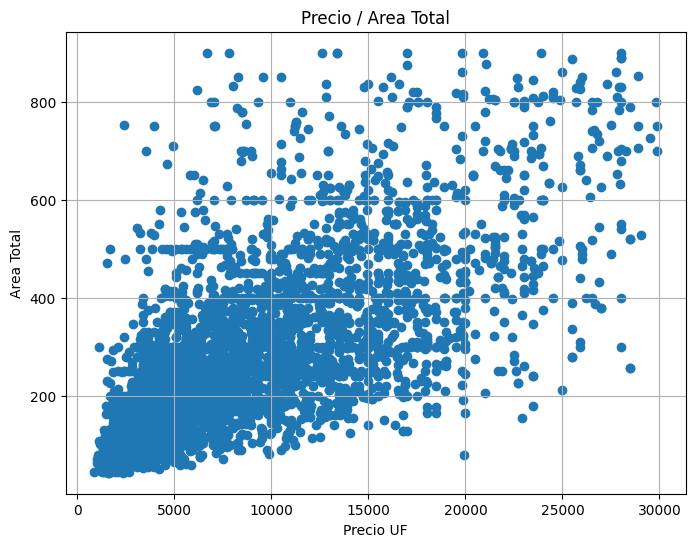

In [94]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean['Price_UF'], df_clean['Total Area'])
plt.title("Precio / Area Total")
plt.xlabel("Precio UF")
plt.ylabel("Area Total")
plt.grid(True)
plt.show()

In [76]:
df_clean.shape

(5970, 8)

In [77]:
df_clean = pd.get_dummies(df_clean, columns=['Comuna'], dtype=int)
df_clean.shape

(5970, 57)

In [78]:
os.makedirs('../data/processed', exist_ok=True)
df_clean.to_csv('../data/processed/casas_chile_limpio.csv', index=False)